<a href="https://colab.research.google.com/github/mugalan/introduction-to-statistical-learning/blob/main/assignments/Bayesian_Inference_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Q. Bayesian Estimation of a User Ability Parameter from Item Responses

An online learning platform presents a user with a sequence of $n$ multiple-choice questions **one at a time**. Each question is either answered correctly or incorrectly, allowing the platform to update its estimate of the user's ability dynamically after every response.

Let $Y_i$ denote the user's response to the $i$-th item encountered:

$$Y_i=
\begin{cases}
1, & \text{if the user answers item } i \text{ correctly},\\
0, & \text{if the user answers item } i \text{ incorrectly}.
\end{cases}$$

The platform assumes that the probability of a correct response is governed by a two-parameter logistic (2PL) item response model. Specifically, conditional on the user's latent ability parameter $\Theta=\theta$, the response probability for item $i$ is:

$$P(Y_i=1\mid \Theta=\theta)=p_i(\theta)=\frac{1}{1+e^{-a_i(\theta-b_i)}},$$

where $a_i>0$ is the known discrimination parameter, and $b_i$ is the known difficulty parameter of item $i$.

Let $\mathbf{y}^{(k)} = (y_1, y_2, \dots, y_k)$ represent the **running vector of observed responses** up to the current step $k$ (where $1 \le k \le n$).

Before observing any responses, the platform initializes the user's latent ability estimate with a standard normal prior distribution:

$$f_{\Theta}^{(0)}(\theta) = \frac{1}{\sqrt{2\pi}} \exp\left(-\frac{\theta^2}{2}\right) \quad \text{implying} \quad \Theta \sim \mathscr{N}(0,1).$$

As the user progresses, the posterior distribution at step $k-1$ serves as the prior distribution for step $k$.

---

### Tasks

1. **Visualizing the Mechanics:** Plot $P(Y_i=1\mid \Theta=\theta)$ vs $\theta$ using Plotly for two distinct values of $a_i$, where one of those $a_i$ values is paired with three different difficulty values of $b_i$. Interpret how moving $b_i$ shifts the curve horizontally.
2. **Sequential Likelihood Contribution:** Write down the likelihood contribution $L(y_k \mid \theta)$ of a *single* new response $y_k$ at step $k$, given the latent ability $\theta$. Then, write down the joint likelihood function for the running history vector $\mathbf{y}^{(k)}$.
3. **Mathematical Formulation of the Running Update:** Write down the recursive relationship for the posterior density at step $k$, denoted $f_{\Theta \mid \mathbf{Y}^{(k)}}(\theta \mid \mathbf{y}^{(k)})$, up to a proportionality constant, using the prior state $f_{\Theta \mid \mathbf{Y}^{(k-1)}}(\theta \mid \mathbf{y}^{(k-1)})$ and the new observation $y_k$.
4. **Dynamic Shifting:** Explain how a correct answer ($y_k = 1$) to a highly difficult item (large $b_k$) mathematically shifts the peak of the running posterior density distribution relative to the previous step.
5. **Tracking Certainty and Sharpness:** Explain how the discrimination parameter $a_k$ of the current item alters the variance (or "sharpness") of the distribution during a running update. What happens when $a_k$ is very large versus very small?
6. **Numerical Implementation of a Running Grid:** Describe a algorithmic approach to numerically approximate and maintain this running posterior density function on a fixed grid of $\theta$-values. Explicitly state how you would perform the sequential normalization step computationally after an item is answered.


7. **Evaluating Convergence over the Timeline:** Suppose the user's true, hidden latent ability is $\theta_{\text{true}} = 0.75$. Write a Python script that extends your previous grid simulation to track the performance of the running estimators over a sequence of $n = 20$ items.
* **Simulate Responses:** Dynamically generate the user's responses $y_k \in \{0, 1\}$ at each step by comparing a random draw from a Uniform distribution $U(0,1)$ against the true response probability $p_k(\theta_{\text{true}})$. Give each item a random difficulty $b_k \sim \mathscr{N}(0, 1)$ and a random discrimination $a_k \sim \text{Uniform}(0.5, 2.0)$.
* **Track Estimators:** At each step $k$, calculate and store the running Posterior Mean ($\widehat{\theta}_{\mathrm{Bayes}}^{(k)}$) and the running Maximum A Posteriori ($\widehat{\theta}_{\mathrm{MAP}}^{(k)}$) estimate.
* **Visualize:** Use Plotly to create a single line chart showing the progression of both estimators from step $0$ to $20$. Add a static horizontal reference line at $y = 0.75$ representing $\theta_{\text{true}}$.
* **Analysis:** Briefly explain how the distance between your estimators and $\theta_{\text{true}}$ changes as $k$ increases, and interpret what this implies about the platform's confidence in its measurement.


## Solutions

### Task 1 — Visualizing the Mechanics

The item response function (item characteristic curve) is

$$p_i(\theta)=\frac{1}{1+e^{-a_i(\theta-b_i)}}.$$

Below, $a_i=1.0$ is paired with three difficulties $b_i\in\{-1.5,0,1.5\}$, and a second, steeper curve uses $a_i=2.5,\ b_i=0$.

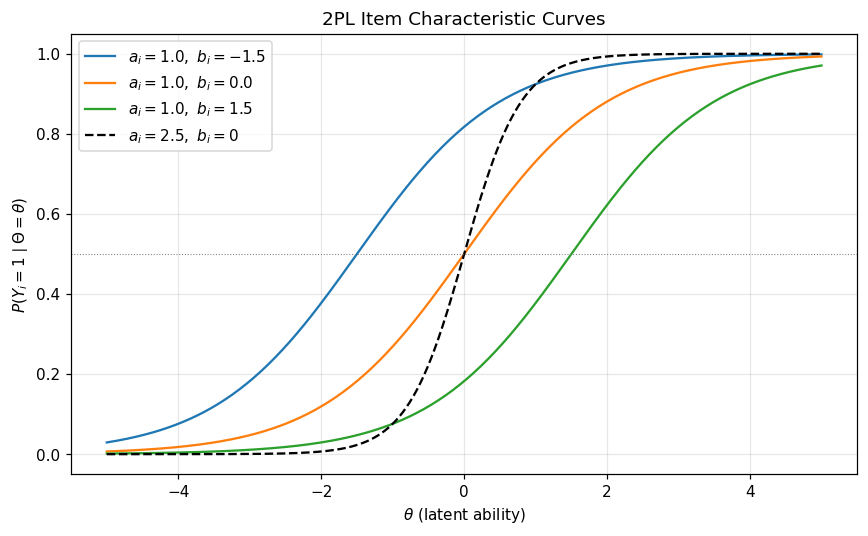

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def p_2pl(theta, a, b):
    return 1.0 / (1.0 + np.exp(-a * (theta - b)))

theta_grid = np.linspace(-5, 5, 400)

fig, ax = plt.subplots(figsize=(8, 5))

for b in [-1.5, 0.0, 1.5]:
    ax.plot(theta_grid, p_2pl(theta_grid, a=1.0, b=b),
            label=f"$a_i=1.0,\\ b_i={b}$")

ax.plot(theta_grid, p_2pl(theta_grid, a=2.5, b=0.0),
        linestyle="--", color="black", label="$a_i=2.5,\\ b_i=0$")

ax.axhline(0.5, color="grey", linewidth=0.7, linestyle=":")
ax.set_xlabel(r"$\theta$ (latent ability)")
ax.set_ylabel(r"$P(Y_i=1\mid\Theta=\theta)$")
ax.set_title("2PL Item Characteristic Curves")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**Interpretation.** For a fixed discrimination $a_i$, changing $b_i$ translates the S-shaped curve rigidly along the $\theta$-axis without changing its shape: the curve always crosses $p_i(\theta)=0.5$ exactly at $\theta=b_i$. A larger $b_i$ shifts the curve to the right, meaning a *higher* ability is required to have even odds of a correct answer — i.e. the item is *harder*. A smaller (more negative) $b_i$ shifts the curve left, so even low-ability users are likely to answer correctly — the item is *easier*. Separately, the discrimination parameter $a_i$ controls the *steepness* of the transition around $\theta=b_i$: the $a_i=2.5$ curve rises much more sharply than the $a_i=1.0$ curve, meaning it discriminates more sharply between users just below vs. just above the difficulty threshold.

### Task 2 — Sequential Likelihood Contribution

Since $Y_k\mid\Theta=\theta$ is Bernoulli with success probability $p_k(\theta)$, the likelihood contribution of a single new response is

$$L(y_k\mid\theta)=p_k(\theta)^{y_k}\,\bigl[1-p_k(\theta)\bigr]^{1-y_k},\qquad y_k\in\{0,1\}.$$

Assuming conditional independence of responses given $\Theta=\theta$ (a standard IRT local-independence assumption), the joint likelihood of the running history $\mathbf{y}^{(k)}=(y_1,\dots,y_k)$ is the product of the individual contributions:

$$L\!\left(\mathbf{y}^{(k)}\mid\theta\right)=\prod_{i=1}^{k} p_i(\theta)^{y_i}\bigl[1-p_i(\theta)\bigr]^{1-y_i}
=\prod_{i=1}^{k}\left[\frac{1}{1+e^{-a_i(\theta-b_i)}}\right]^{y_i}\left[\frac{e^{-a_i(\theta-b_i)}}{1+e^{-a_i(\theta-b_i)}}\right]^{1-y_i}.$$

### Task 3 — Mathematical Formulation of the Running Update

By Bayes' theorem applied at step $k$, with $f_{\Theta\mid\mathbf{Y}^{(k-1)}}(\theta\mid\mathbf{y}^{(k-1)})$ playing the role of the prior for the new observation $y_k$:

$$f_{\Theta\mid\mathbf{Y}^{(k)}}\!\left(\theta\mid\mathbf{y}^{(k)}\right)
=\frac{L(y_k\mid\theta)\,f_{\Theta\mid\mathbf{Y}^{(k-1)}}\!\left(\theta\mid\mathbf{y}^{(k-1)}\right)}
{\displaystyle\int_{-\infty}^{\infty} L(y_k\mid\theta')\,f_{\Theta\mid\mathbf{Y}^{(k-1)}}\!\left(\theta'\mid\mathbf{y}^{(k-1)}\right)\,d\theta'}
\;\propto\; L(y_k\mid\theta)\;f_{\Theta\mid\mathbf{Y}^{(k-1)}}\!\left(\theta\mid\mathbf{y}^{(k-1)}\right).$$

That is, **new posterior $\propto$ likelihood of the newest observation $\times$ old posterior**. This recursive relation is what makes online (streaming) Bayesian updating possible: we never need to revisit $y_1,\dots,y_{k-1}$ directly, because all of their information has already been absorbed into $f_{\Theta\mid\mathbf{Y}^{(k-1)}}$.

### Task 4 — Dynamic Shifting

A correct answer ($y_k=1$) contributes the likelihood factor $L(1\mid\theta)=p_k(\theta)$, which is an *increasing* function of $\theta$ (it rises from 0 to 1 as $\theta$ goes from $-\infty$ to $\infty$, crossing $0.5$ at $\theta=b_k$). Multiplying the previous posterior by this increasing factor reweights probability mass toward larger $\theta$ — i.e. the peak of $f_{\Theta\mid\mathbf{Y}^{(k)}}$ shifts to the **right** of the peak of $f_{\Theta\mid\mathbf{Y}^{(k-1)}}$.

The *size* of that shift depends on where the reweighting curve is "centered" relative to the current belief. If item $k$ is very difficult (large $b_k$) and the user still answers it correctly, then $p_k(\theta)$ is close to $0$ for all $\theta$ in the bulk of the current posterior and only becomes appreciable for $\theta$ near or above $b_k$. Because a large $b_k$ places the steep part of $p_k(\theta)$ far to the right, a correct response to such a hard item multiplies the current posterior by a factor that is *very small* for the plausible values under the old posterior and grows rapidly only well to the right — so the reweighting is very selective, and the posterior mass is pulled strongly toward $\theta\gtrsim b_k$. In short: **a correct answer on a hard item produces a large rightward shift**, because it is much more informative about high ability than a correct answer on an easy item (for which $p_k(\theta)\approx 1$ almost everywhere already, so the reweighting barely changes the shape).

### Task 5 — Tracking Certainty and Sharpness

The discrimination parameter $a_k$ controls the *slope* of $p_k(\theta)$ around $\theta=b_k$: since
$$\frac{\partial p_k(\theta)}{\partial \theta}=a_k\,p_k(\theta)\bigl[1-p_k(\theta)\bigr],$$
larger $a_k$ makes $p_k(\theta)$ transition from near $0$ to near $1$ over a *narrower* window of $\theta$ around $b_k$. As a likelihood factor multiplying the running posterior, a large $a_k$ therefore acts almost like an indicator function: it strongly *discounts* values of $\theta$ on the "wrong side" of $b_k$ (inconsistent with the observed $y_k$) while barely discounting values on the "right side." This produces a sharp, aggressive narrowing of the posterior around the region consistent with the response — i.e. it *reduces the posterior variance* substantially (high information / high certainty gain).

- **$a_k \to \infty$:** $p_k(\theta)$ approaches a step function at $\theta=b_k$. The response becomes almost deterministic given $\theta$, so observing $y_k$ is highly informative — the posterior gets multiplied by something close to a one-sided indicator, producing a sharp cut and a large drop in variance.
- **$a_k \to 0$:** $p_k(\theta)\to 0.5$ for all $\theta$, i.e. the item's outcome carries essentially no information about $\theta$ (a coin flip regardless of ability). The likelihood factor is nearly flat, so the posterior is barely updated — the running density keeps almost the same shape (and variance) as before the observation.

### Task 6 — Numerical Implementation of a Running Grid

1. **Discretize.** Choose a fixed, sufficiently fine grid $\theta_1<\theta_2<\dots<\theta_M$ spanning the plausible ability range (e.g. $[-5,5]$ with $M\sim 400$–$1000$ points).
2. **Initialize.** Evaluate the prior density on the grid: $f^{(0)}_j=f_\Theta^{(0)}(\theta_j)=\mathcal N(\theta_j;0,1)$ for $j=1,\dots,M$.
3. **Sequential update.** When item $k$ is answered (observed $y_k$, with known $a_k,b_k$):
   - Compute $p_k(\theta_j)=\dfrac{1}{1+e^{-a_k(\theta_j-b_k)}}$ on the grid.
   - Compute the likelihood vector $L_j=p_k(\theta_j)^{y_k}\bigl[1-p_k(\theta_j)\bigr]^{1-y_k}$.
   - Form the unnormalized posterior: $\tilde f^{(k)}_j=f^{(k-1)}_j\cdot L_j$.
4. **Sequential normalization.** Numerically integrate the unnormalized values using a quadrature rule (e.g. the trapezoidal rule via `numpy.trapezoid`) to get the normalizing constant
   $$Z_k=\int \tilde f^{(k)}(\theta)\,d\theta \approx \texttt{np.trapezoid}(\tilde f^{(k)}_j,\ \theta_j),$$
   then set $f^{(k)}_j=\tilde f^{(k)}_j / Z_k$ so that $\sum_j f^{(k)}_j \Delta\theta \approx 1$ (or, more precisely, so the trapezoidal integral equals 1).
5. **Point estimates.** After normalizing, compute the running posterior mean as $\widehat\theta^{(k)}_{\text{Bayes}}=\texttt{np.trapezoid}(\theta_j f^{(k)}_j,\ \theta_j)$ and the running MAP as $\widehat\theta^{(k)}_{\text{MAP}}=\theta_{j^\*}$ where $j^\*=\arg\max_j f^{(k)}_j$.
6. **Repeat** steps 3–5 for each incoming item, always using the just-computed $f^{(k)}$ as next step's prior — this is exactly the recursive relation from Task 3, implemented on a discretized grid.

### Task 7 — Evaluating Convergence over the Timeline

Final posterior mean estimate:  0.5905
Final MAP estimate:             0.5656
True ability:                   0.7500


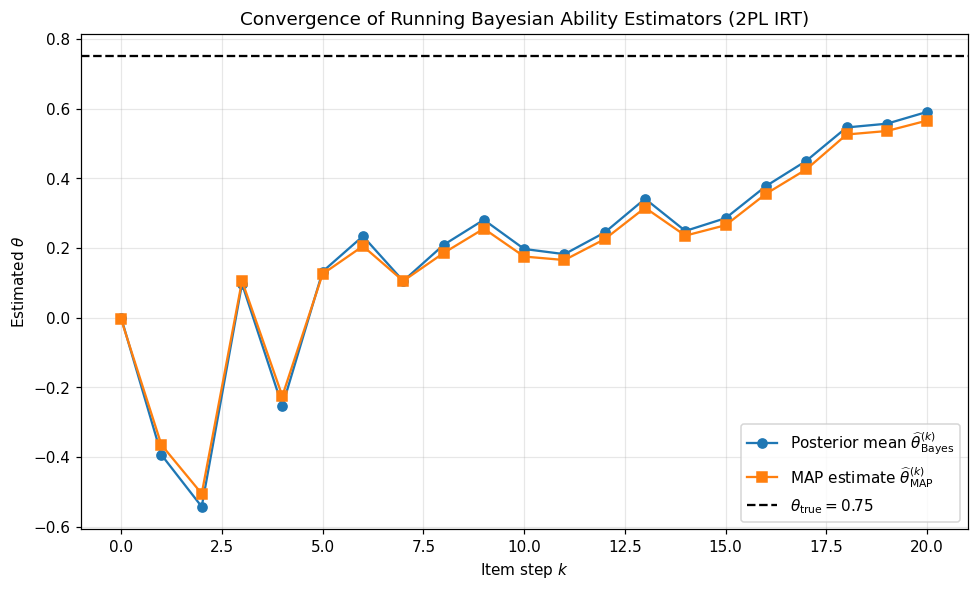

In [2]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

theta_true = 0.75
n_items = 20

# Fixed grid for theta
theta_grid = np.linspace(-5, 5, 1000)

# Prior: standard normal
posterior = (1.0 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * theta_grid**2)
posterior /= np.trapezoid(posterior, theta_grid)   # normalize (should already integrate ~1)

bayes_estimates = [np.trapezoid(theta_grid * posterior, theta_grid)]
map_estimates = [theta_grid[np.argmax(posterior)]]

for k in range(1, n_items + 1):
    b_k = rng.normal(0, 1)
    a_k = rng.uniform(0.5, 2.0)

    p_true = p_2pl(theta_true, a_k, b_k)
    y_k = 1 if rng.uniform(0, 1) < p_true else 0

    p_grid = p_2pl(theta_grid, a_k, b_k)
    likelihood = p_grid**y_k * (1 - p_grid) ** (1 - y_k)

    unnorm_posterior = posterior * likelihood
    Z = np.trapezoid(unnorm_posterior, theta_grid)
    posterior = unnorm_posterior / Z

    bayes_estimates.append(np.trapezoid(theta_grid * posterior, theta_grid))
    map_estimates.append(theta_grid[np.argmax(posterior)])

steps = np.arange(0, n_items + 1)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(steps, bayes_estimates, marker="o", label=r"Posterior mean $\widehat{\theta}_{\mathrm{Bayes}}^{(k)}$")
ax.plot(steps, map_estimates, marker="s", label=r"MAP estimate $\widehat{\theta}_{\mathrm{MAP}}^{(k)}$")
ax.axhline(theta_true, color="black", linestyle="--", label=r"$\theta_{\text{true}}=0.75$")
ax.set_xlabel("Item step $k$")
ax.set_ylabel(r"Estimated $\theta$")
ax.set_title("Convergence of Running Bayesian Ability Estimators (2PL IRT)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Final posterior mean estimate:  {bayes_estimates[-1]:.4f}")
print(f"Final MAP estimate:             {map_estimates[-1]:.4f}")
print(f"True ability:                   {theta_true:.4f}")


**Analysis.** Early in the sequence (small $k$) the estimators are still heavily influenced by the flat, uninformative $\mathcal N(0,1)$ prior and by the small number of noisy Bernoulli observations, so $\widehat\theta_{\text{Bayes}}^{(k)}$ and $\widehat\theta_{\text{MAP}}^{(k)}$ can wander noticeably and may lie fairly far from $\theta_{\text{true}}=0.75$. As $k$ grows, more evidence accumulates (each new item multiplies in another likelihood factor), the posterior progressively narrows, and — provided enough items have reasonable discrimination $a_k$ near the user's true ability region — both estimators tend to drift toward and stabilize near $\theta_{\text{true}}$, with the gap $|\widehat\theta^{(k)}-\theta_{\text{true}}|$ shrinking on average (though not strictly monotonically, since each new $y_k$ is still a single noisy binary draw). This reflects the general Bayesian consistency property: as more informative data accumulate, the posterior concentrates around the true parameter value, and the platform becomes increasingly confident (lower posterior variance) in its ability estimate.

# Q. Bayesian Tracking of Click-Through Rates (CTR) via Conjugate Beta-Binomial Updates

An e-commerce platform wants to optimize its recommendation engine by dynamically estimating the click-through rate (CTR) of a newly launched advertisement. Since user traffic arrives continuously, the platform updates its belief about the advertisement's performance **one impression at a time** rather than waiting for large batch updates.

Let $\Theta = \theta$ represent the true, hidden conversion rate (probability of a click) of the advertisement, where $\theta \in [0, 1]$.

Let $Y_k$ denote a single user's interaction with the advertisement at time step $k$:

$$Y_k =
\begin{cases}
1, & \text{if the user clicks the advertisement}, \\
0, & \text{if the user does not click the advertisement}.
\end{cases}$$

The platform assumes that conditional on the true conversion rate $\Theta = \theta$, each user interaction is an independent Bernoulli trial:

$$P(Y_k = 1 \mid \Theta = \theta) = \theta$$

Let $\mathbf{y}^{(k)} = (y_1, y_2, \dots, y_k)$ represent the **running vector of observed user interactions** up to the current impression step $k$ (where $1 \le k \le n$).

Before observing any data, the platform assigns a flexible **Beta distribution** as the initial prior over the unknown parameter $\Theta$:

$$f_{\Theta}^{(0)}(\theta) = \frac{1}{\mathrm{B}(\alpha_0, \beta_0)} \theta^{\alpha_0 - 1} (1 - \theta)^{\beta_0 - 1} \quad \text{implying} \quad \Theta \sim \text{Beta}(\alpha_0, \beta_0)$$

where $\mathrm{B}(\cdot, \cdot)$ is the Beta function acting as the normalizing constant. Under a sequential framework, the posterior distribution at step $k-1$ serves directly as the prior distribution for step $k$.

---

**Tasks**

**1. Structural Probability and Properties**
Plot the probability density function (PDF) of a $\text{Beta}(\alpha, \beta)$ distribution using Plotly for three distinct parameter pairs:

* Uninformative state: $(\alpha=1, \beta=1)$
* Right-skewed state: $(\alpha=2, \beta=8)$
* Left-skewed state: $(\alpha=8, \beta=2)$

Interpret how changing the balance between $\alpha$ and $\beta$ shifts the center of mass of the density function over the domain $[0, 1]$.

**2. Sequential Likelihood and Joint History**

Write down the mathematical likelihood contribution $L(y_k \mid \theta)$ of a *single* isolated response $y_k$ at step $k$, given the click probability $\theta$. Following this, express the joint likelihood function for the running history vector $\mathbf{y}^{(k)}$.

**3. Closed-Form Analytical Updates (Conjugacy)**

Using Bayes' Theorem, derive the recursive algebraic relationship for the posterior density at step $k$, denoted as $f_{\Theta \mid \mathbf{Y}^{(k)}}(\theta \mid \mathbf{y}^{(k)})$. Prove analytically that the posterior remains in the Beta family (**Beta-Binomial Conjugacy**) by explicitly writing down the closed-form update parameters $\alpha_k$ and $\beta_k$ as simple arithmetic updates of $\alpha_{k-1}$, $\beta_{k-1}$, and $y_k$. Also compute the **Posterior Mean** of the latent parameter $\Theta$ at time step $k$ (i.e. $\mathbb{E}[\Theta \mid \mathbf{Y}^{(k)}=\mathbf{y}^{(k)}]$).


**4. Dynamic Shifting Mechanics**

Explain how an observed click ($y_k = 1$) vs. a non-click ($y_k = 0$) shifts the peak of the running density distribution mathematically. Contrast this analytical framework against non-conjugate setups (such as the 2PL IRT model) where numerical grid integration is strictly required.

**5. Running Point Estimators**

State the exact closed-form equations used to evaluate the following point estimates at step $k$ directly from the updated shape parameters $\alpha_k$ and $\beta_k$:

* **Running Posterior Mean** ($\widehat{\theta}_{\mathrm{Bayes}}^{(k)}$)
* **Running Maximum A Posteriori** ($\widehat{\theta}_{\mathrm{MAP}}^{(k)}$)

**6. Performance Tracking and Convergence Analysis**

Suppose the advertisement's true, hidden click-through rate is $\theta_{\text{true}} = 0.35$. Write a Python script to track the performance of your closed-form sequential estimators over a timeline of $n = 100$ impressions:

* **Initialize State:** Set the base prior parameters to $\alpha_0 = 1, \beta_0 = 1$ (representing uniform initial uncertainty).
* **Simulate Responses:** Dynamically generate user responses $y_k \in \{0, 1\}$ at each step by comparing a random draw from a Uniform distribution $U(0,1)$ against $\theta_{\text{true}}$.
* **Track Estimators:** Loop through each step, update $\alpha_k$ and $\beta_k$ analytically, and store the computed values for $\widehat{\theta}_{\mathrm{Bayes}}^{(k)}$ and $\widehat{\theta}_{\mathrm{MAP}}^{(k)}$.
* **Visualize:** Use Plotly to create a single line chart showing the progression of both estimators from step $0$ to $100$. Add a static horizontal reference line at $y = 0.35$ representing $\theta_{\text{true}}$.
* **Analysis:** Explain how the distance between your estimators and $\theta_{\text{true}}$ responds as the sampling size $k$ approaches $100$. What does this imply about the accumulation of evidence over time relative to the choice of the initial prior?

## Solutions

### Task 1 — Structural Probability and Properties

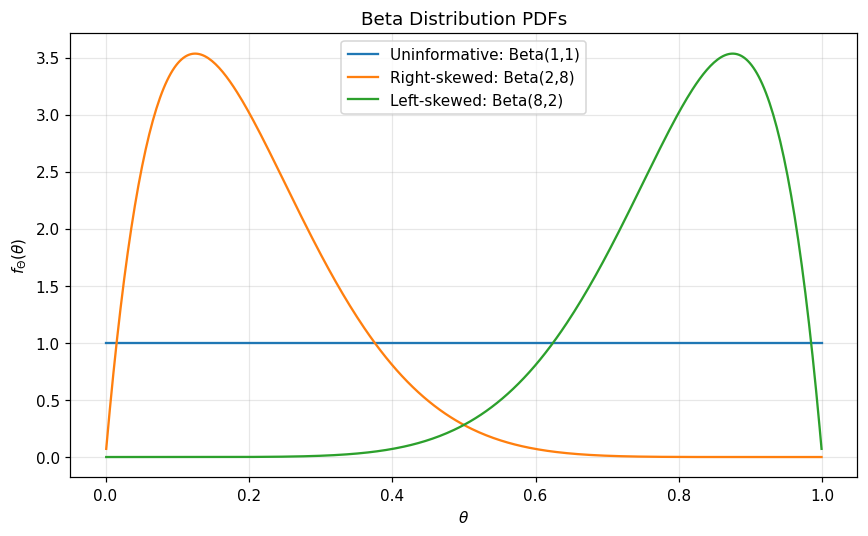

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta as beta_dist

theta_grid01 = np.linspace(0.001, 0.999, 400)

params = [(1, 1, "Uninformative: Beta(1,1)"),
          (2, 8, "Right-skewed: Beta(2,8)"),
          (8, 2, "Left-skewed: Beta(8,2)")]

fig, ax = plt.subplots(figsize=(8, 5))
for a_, b_, label in params:
    ax.plot(theta_grid01, beta_dist.pdf(theta_grid01, a_, b_), label=label)

ax.set_xlabel(r"$\theta$")
ax.set_ylabel(r"$f_\Theta(\theta)$")
ax.set_title("Beta Distribution PDFs")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**Interpretation.** The mean of a $\text{Beta}(\alpha,\beta)$ distribution is $\mathbb E[\Theta]=\alpha/(\alpha+\beta)$, so the balance between $\alpha$ and $\beta$ directly controls where the density's center of mass sits in $[0,1]$: $\text{Beta}(1,1)$ is the uniform distribution (no preference, mean $0.5$); $\text{Beta}(2,8)$ has mean $0.2$ and is pulled toward $0$ (right-skewed, most mass at low $\theta$ — representing a belief that the click rate is likely low); $\text{Beta}(8,2)$ has mean $0.8$ and is pulled toward $1$ (left-skewed, most mass at high $\theta$). More generally, increasing $\alpha$ relative to $\beta$ shifts mass rightward (toward $1$), while increasing $\beta$ relative to $\alpha$ shifts mass leftward (toward $0$); the sum $\alpha+\beta$ controls how concentrated (peaked) the density is around that mean.

### Task 2 — Sequential Likelihood and Joint History

Since $Y_k\mid\Theta=\theta \sim \text{Bernoulli}(\theta)$, the single-observation likelihood contribution is

$$L(y_k\mid\theta)=\theta^{y_k}(1-\theta)^{1-y_k},\qquad y_k\in\{0,1\}.$$

Assuming the interactions are conditionally independent given $\Theta=\theta$, the joint likelihood of the running history $\mathbf y^{(k)}=(y_1,\dots,y_k)$ is

$$L\!\left(\mathbf y^{(k)}\mid\theta\right)=\prod_{i=1}^{k}\theta^{y_i}(1-\theta)^{1-y_i}=\theta^{\sum_{i=1}^k y_i}(1-\theta)^{k-\sum_{i=1}^k y_i}=\theta^{S_k}(1-\theta)^{k-S_k},$$

where $S_k=\sum_{i=1}^k y_i$ is the running number of clicks.

### Task 3 — Closed-Form Analytical Updates (Conjugacy)

By Bayes' theorem, using the step-$(k-1)$ posterior as the prior for step $k$:

$$f_{\Theta\mid\mathbf Y^{(k)}}(\theta\mid\mathbf y^{(k)}) \propto L(y_k\mid\theta)\;f_{\Theta\mid\mathbf Y^{(k-1)}}(\theta\mid\mathbf y^{(k-1)}).$$

Suppose (induction hypothesis) that $f_{\Theta\mid\mathbf Y^{(k-1)}}(\theta\mid\mathbf y^{(k-1)}) = \dfrac{1}{\mathrm B(\alpha_{k-1},\beta_{k-1})}\theta^{\alpha_{k-1}-1}(1-\theta)^{\beta_{k-1}-1}$, i.e. $\Theta\mid\mathbf y^{(k-1)}\sim\text{Beta}(\alpha_{k-1},\beta_{k-1})$ (true at $k=1$ since $\Theta\sim\text{Beta}(\alpha_0,\beta_0)$ before any data). Then

$$f_{\Theta\mid\mathbf Y^{(k)}}(\theta\mid\mathbf y^{(k)}) \propto \theta^{y_k}(1-\theta)^{1-y_k}\cdot\theta^{\alpha_{k-1}-1}(1-\theta)^{\beta_{k-1}-1}=\theta^{(\alpha_{k-1}+y_k)-1}(1-\theta)^{(\beta_{k-1}+1-y_k)-1}.$$

This is exactly the *unnormalized* kernel of a $\text{Beta}(\alpha_{k-1}+y_k,\ \beta_{k-1}+1-y_k)$ density. Since the Beta family is closed under this reweighting (the normalizing constant is simply the Beta function of the new parameters), the posterior is again Beta — this is the **Beta-Binomial conjugacy** property. The closed-form recursive updates are

$$\boxed{\alpha_k=\alpha_{k-1}+y_k,\qquad \beta_k=\beta_{k-1}+(1-y_k).}$$

In words: $\alpha$ increases by 1 on a click, $\beta$ increases by 1 on a non-click. Equivalently, after $k$ observations with $S_k=\sum_{i=1}^k y_i$ clicks: $\alpha_k=\alpha_0+S_k,\ \beta_k=\beta_0+k-S_k$.

The **posterior mean** at step $k$ follows directly from the Beta distribution's mean formula:

$$\mathbb E\!\left[\Theta\mid\mathbf Y^{(k)}=\mathbf y^{(k)}\right]=\frac{\alpha_k}{\alpha_k+\beta_k}=\frac{\alpha_0+S_k}{\alpha_0+\beta_0+k}.$$

### Task 4 — Dynamic Shifting Mechanics

Each update simply increments one shape parameter by 1: a click ($y_k=1$) sets $\alpha_k=\alpha_{k-1}+1,\ \beta_k=\beta_{k-1}$, which pushes the posterior mean $\alpha_k/(\alpha_k+\beta_k)$ **upward** (toward 1) and shifts the density's peak to the right. A non-click ($y_k=0$) sets $\alpha_k=\alpha_{k-1},\ \beta_k=\beta_{k-1}+1$, pushing the mean **downward** (toward 0) and shifting the peak left. The *magnitude* of each shift shrinks as $\alpha_{k-1}+\beta_{k-1}$ (the "effective sample size" already absorbed into the prior/posterior) grows — a single new observation matters less once a lot of evidence has already accumulated, since it changes the ratio $\alpha_k/(\alpha_k+\beta_k)$ by a progressively smaller amount.

This is in sharp contrast with the non-conjugate 2PL IRT setting of Question 1: there, multiplying a Gaussian-like prior by the logistic-shaped likelihood factor $p_k(\theta)^{y_k}[1-p_k(\theta)]^{1-y_k}$ does **not** produce a density in any simple closed family, so the resulting posterior has no analytic normalizing constant, mean, or mode — these must be approximated numerically (e.g. via the grid-and-trapezoidal-rule approach of Task 6 there). Here, because the Bernoulli likelihood is conjugate to the Beta prior, every update is a simple, exact, $O(1)$ arithmetic increment with no numerical integration required at any step.

### Task 5 — Running Point Estimators

Directly from the properties of the $\text{Beta}(\alpha_k,\beta_k)$ posterior:

$$\widehat{\theta}_{\mathrm{Bayes}}^{(k)}=\mathbb E[\Theta\mid \mathbf y^{(k)}]=\frac{\alpha_k}{\alpha_k+\beta_k},$$

$$\widehat{\theta}_{\mathrm{MAP}}^{(k)}=\frac{\alpha_k-1}{\alpha_k+\beta_k-2}\qquad(\text{valid when } \alpha_k>1 \text{ and } \beta_k>1),$$

since the Beta$(\alpha_k,\beta_k)$ density $\theta^{\alpha_k-1}(1-\theta)^{\beta_k-1}$ is maximized (by differentiating the log-density and setting to zero) at $\theta=(\alpha_k-1)/(\alpha_k+\beta_k-2)$ when both shape parameters exceed 1. (If $\alpha_k\le 1$ or $\beta_k\le 1$ the mode instead lies at a boundary, $0$ or $1$, or the density is U-shaped/unbounded — this edge case does not arise here once $\alpha_0=\beta_0=1$ and at least one observation of each type has been seen.)

### Task 6 — Performance Tracking and Convergence Analysis

Final alpha_k, beta_k:  (37, 65)
Final posterior mean:   0.3627
Final MAP estimate:     0.3600
True CTR:               0.3500


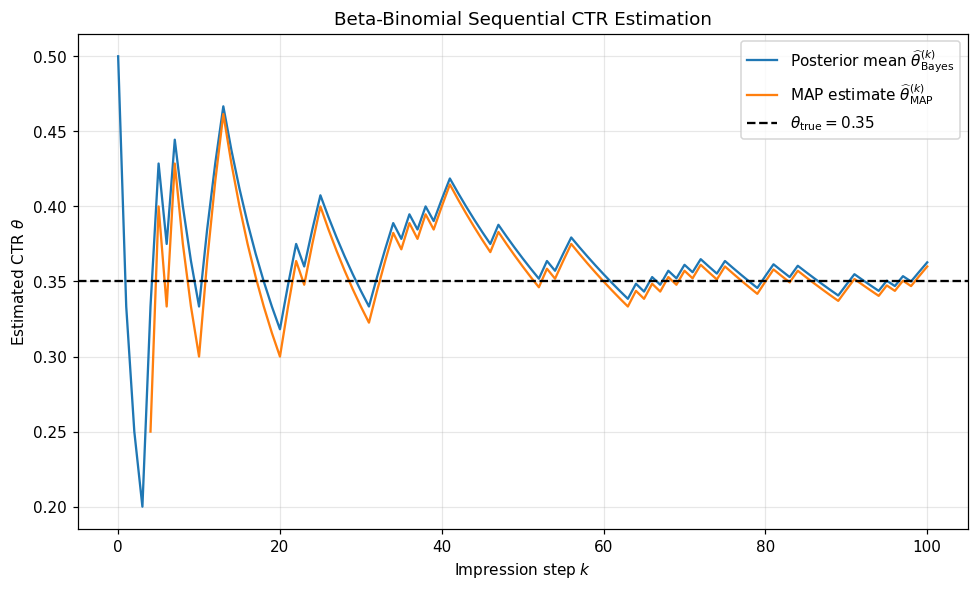

In [4]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(7)

theta_true = 0.35
n_impressions = 100
alpha0, beta0 = 1.0, 1.0

alpha_k, beta_k = alpha0, beta0
bayes_estimates = [alpha_k / (alpha_k + beta_k)]
map_estimates = [np.nan]  # MAP undefined for Beta(1,1) (flat distribution)

for k in range(1, n_impressions + 1):
    y_k = 1 if rng.uniform(0, 1) < theta_true else 0
    alpha_k += y_k
    beta_k += (1 - y_k)

    bayes_estimates.append(alpha_k / (alpha_k + beta_k))
    if alpha_k > 1 and beta_k > 1:
        map_estimates.append((alpha_k - 1) / (alpha_k + beta_k - 2))
    else:
        map_estimates.append(np.nan)

steps = np.arange(0, n_impressions + 1)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(steps, bayes_estimates, label=r"Posterior mean $\widehat{\theta}_{\mathrm{Bayes}}^{(k)}$")
ax.plot(steps, map_estimates, label=r"MAP estimate $\widehat{\theta}_{\mathrm{MAP}}^{(k)}$")
ax.axhline(theta_true, color="black", linestyle="--", label=r"$\theta_{\text{true}}=0.35$")
ax.set_xlabel("Impression step $k$")
ax.set_ylabel(r"Estimated CTR $\theta$")
ax.set_title("Beta-Binomial Sequential CTR Estimation")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Final alpha_k, beta_k:  ({alpha_k:.0f}, {beta_k:.0f})")
print(f"Final posterior mean:   {bayes_estimates[-1]:.4f}")
print(f"Final MAP estimate:     {map_estimates[-1]:.4f}")
print(f"True CTR:               {theta_true:.4f}")


**Analysis.** With the uninformative $\text{Beta}(1,1)$ prior, the posterior mean starts at exactly $0.5$ (before any data) and can move substantially with the very first few impressions, since each observation still changes $\alpha_k/(\alpha_k+\beta_k)$ by a large relative amount when $\alpha_k+\beta_k$ is small. As $k\to100$, the accumulated impressions dominate the (weak) prior: $\alpha_0+\beta_0=2$ becomes negligible compared to $k=100$, so $\widehat\theta_{\text{Bayes}}^{(k)}\approx S_k/k$, the empirical click rate, and both estimators converge toward $\theta_{\text{true}}=0.35$ with progressively smaller step-to-step fluctuations (the posterior variance of a Beta$(\alpha_k,\beta_k)$ is $\alpha_k\beta_k/[(\alpha_k+\beta_k)^2(\alpha_k+\beta_k+1)]$, which shrinks roughly like $1/k$). This illustrates a general Bayesian principle: **the influence of the initial prior is asymptotically washed out by accumulating data** — an uninformative prior is quickly overwhelmed, and after enough impressions the estimate essentially reflects the data alone, regardless of the (reasonable) starting point chosen for $\alpha_0,\beta_0$.

# Q Bayesian Estimations for Structural Health Monitoring via Bounded Grid Updates

In aerospace and civil engineering, Structural Health Monitoring (SHM) is critical for detecting damage before a catastrophic failure occurs. Consider an aircraft wing or a bridge girder equipped with specialized vibration sensors. Over time, environmental fatigue or dynamic impacts can cause micro-fractures, resulting in a reduction of the component's mechanical stiffness.

Let $\Theta = \theta$ represent the structural **remaining stiffness efficiency factor**, where $\theta$ is physically bounded to the interval:

$$\theta \in (0, 1]$$

* $\theta = 1.0$ indicates a perfectly pristine, undamaged structural component.
* $\theta \to 0$ signifies critical degradation or severe structural cracking.

Let $K_{\text{nominal}}$ be the known, baseline stiffness of the structural component when it is entirely healthy. At each sequential inspection time step $k$ (where $k = 1, 2, \dots, n$), a sensor collects a noisy experimental stiffness measurement $y_k$.

Engineers model the degradation physics via a non-linear relationship with multiplicative log-normal measurement noise to prevent non-physical negative values:

$$y_k = \theta \cdot K_{\text{nominal}} \cdot e^{\epsilon_k}, \qquad \epsilon_k \sim \mathscr{N}(0, \sigma^2)$$

where $\sigma$ is the standard deviation of the sensor noise in log-space.

Let $\mathbf{y}^{(k)} = (y_1, y_2, \dots, y_k)$ represent the **running history vector of observed sensor readings** up to the current inspection milestone. Before deploying the sensors, engineers utilize an initial prior distribution $f_{\Theta}^{(0)}(\theta)$ over the domain $(0, 1]$ based on historical manufacturing specifications. As the sensor stream arrives, the posterior distribution calculated at step $k-1$ serves directly as the prior distribution for step $k$.

---

### **Tasks**

#### **1. Prior Belief Boundaries**

Before data collection begins, engineers assume the component is highly likely to be healthy, modeling this using a bounded Beta distribution as the initial prior: $\Theta \sim \text{Beta}(8, 1.5)$.

* Plot this initial prior density function using Plotly over the restricted physical domain $\theta \in [0.01, 1.0]$.
* Calculate the expected prior stiffness efficiency $\mathbb{E}[\Theta^{(0)}]$ analytically. Explain why this specific distribution serves as an appropriate initial prior for an engineering component assumed to be healthy.

#### **2. Structural Likelihood Formulation**

Using the change of variables or properties of the log-normal distribution, write down the mathematical likelihood contribution $L(y_k \mid \theta)$ of a *single* continuous sensor measurement $y_k$ at inspection step $k$, given the true stiffness factor $\theta$. Following this, write down the joint likelihood function for the running history vector $\mathbf{y}^{(k)}$.

#### **3. Mathematical Formulation of the Non-Conjugate Grid Update**

Explain why an exact closed-form analytical solution for the posterior density $f_{\Theta \mid \mathbf{Y}^{(k)}}(\theta \mid \mathbf{y}^{(k)})$ does not exist when combining a Beta prior with this log-normal structural likelihood. Write down the recursive relationship for the posterior density at step $k$ up to a proportionality constant.

#### **4. Running Point Estimates**

Because a closed-form formula is unavailable, we must define point estimators through numerical integration. Write down the definite integral equations over the bounded domain $(0, 1]$ required to compute:

* The **Running Posterior Mean** ($\widehat{\theta}_{\mathrm{Bayes}}^{(k)}$)
* The **Running Maximum A Posteriori** ($\widehat{\theta}_{\mathrm{MAP}}^{(k)}$)

#### **5. Algorithmic Grid Approximation and Normalization**

Describe the step-by-step numerical procedure to maintain this distribution on a discrete grid of $\theta$-values. Explicitly state how you would handle the boundary limits computationally and how you would perform the sequential normalization step using the trapezoidal rule after a new sensor reading $y_k$ is observed.

#### **6. Performance Tracking and Degradation Convergence Analysis**

Suppose an impact occurs, and the true, hidden remaining stiffness drops to $\theta_{\text{true}} = 0.68$. Write a Python script using Plotly to simulate an engineered monitoring timeline across $n = 15$ continuous sensor measurements ($K_{\text{nominal}} = 50.0 \text{ kN/mm}$, $\sigma = 0.15$):

* **Simulate Sensor Stream:** Programmatically generate noisy sensor readings $y_k$ by drawing random values from the underlying log-normal physics model centered at $\theta_{\text{true}}$.
* **Track Estimators:** Loop sequentially through each step. At each step, update the unnormalized grid, normalize it via `np.trapezoid`, and compute both $\widehat{\theta}_{\mathrm{Bayes}}^{(k)}$ and $\widehat{\theta}_{\mathrm{MAP}}^{(k)}$.
* **Visualize Curves & Timeline:** Generate two plots:
1. A plot showing the progression of the full posterior density curves at milestones $k \in \{0, 1, 2, 5, 10, 15\}$.
2. A line chart tracking the convergence of both $\widehat{\theta}_{\mathrm{Bayes}}^{(k)}$ and $\widehat{\theta}_{\mathrm{MAP}}^{(k)}$ from step $0$ to $15$ against a horizontal reference line at $\theta_{\text{true}} = 0.68$.


* **Analysis:** Evaluate the behavior of the distribution. How many sensor readings did it take for the system to overcome the initially optimistic "healthy" prior and confidently isolate the 68% damage state? What does the narrowing of the density curves imply about structural safety thresholds?

## Solutions

### Task 1 — Prior Belief Boundaries

E[Theta^(0)] = alpha0/(alpha0+beta0) = 8.0/9.5 = 0.8421


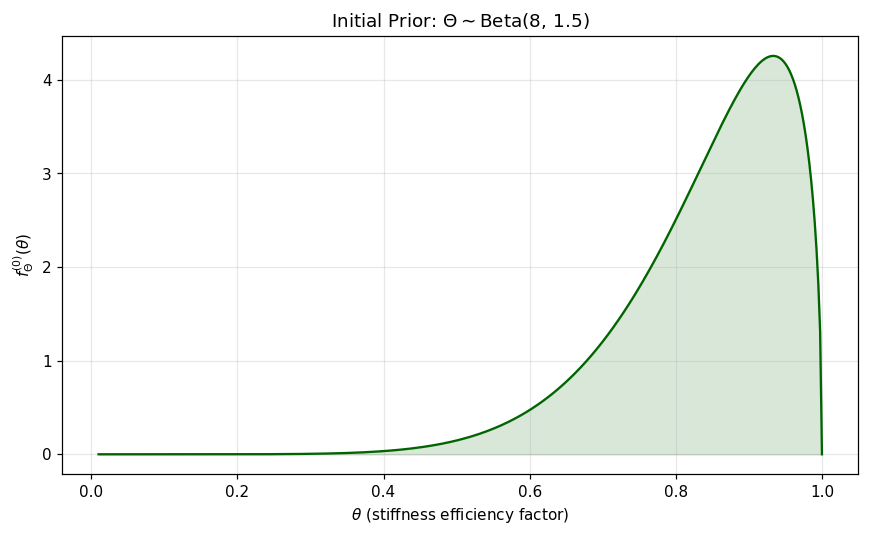

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta as beta_dist

alpha0_shm, beta0_shm = 8.0, 1.5
theta_grid_shm = np.linspace(0.01, 1.0, 400)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(theta_grid_shm, beta_dist.pdf(theta_grid_shm, alpha0_shm, beta0_shm), color="darkgreen")
ax.fill_between(theta_grid_shm, beta_dist.pdf(theta_grid_shm, alpha0_shm, beta0_shm), alpha=0.15, color="darkgreen")
ax.set_xlabel(r"$\theta$ (stiffness efficiency factor)")
ax.set_ylabel(r"$f_\Theta^{(0)}(\theta)$")
ax.set_title(r"Initial Prior: $\Theta \sim \mathrm{Beta}(8,\,1.5)$")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

E_theta0 = alpha0_shm / (alpha0_shm + beta0_shm)
print(f"E[Theta^(0)] = alpha0/(alpha0+beta0) = {alpha0_shm}/{alpha0_shm+beta0_shm} = {E_theta0:.4f}")


The prior mean is $\mathbb E[\Theta^{(0)}]=\dfrac{\alpha_0}{\alpha_0+\beta_0}=\dfrac{8}{9.5}\approx 0.8421$. This $\text{Beta}(8,1.5)$ places most of its density close to $\theta=1$ and decays sharply toward $0$, reflecting the engineering assumption that a newly deployed / recently inspected component is *very likely to be close to pristine* ($\theta\approx 1$) rather than already damaged, while still assigning non-negligible probability to somewhat lower stiffness values to account for manufacturing tolerances. It is an appropriate initial prior because it is supported entirely on the physically valid domain $(0,1]$, is strongly concentrated near the "healthy" end, and — being a Beta distribution — is flexible enough to be dominated by evidence (sensor data) once real degradation is observed.

### Task 2 — Structural Likelihood Formulation

Given $\Theta=\theta$, the model is $Y_k=\theta K_{\text{nominal}}e^{\epsilon_k}$ with $\epsilon_k\sim\mathcal N(0,\sigma^2)$. Equivalently, $\ln Y_k \mid \Theta=\theta \sim \mathcal N\bigl(\ln(\theta K_{\text{nominal}}),\ \sigma^2\bigr)$, i.e. $Y_k\mid\Theta=\theta$ follows a **log-normal** distribution with (log-scale) mean $\ln(\theta K_{\text{nominal}})$ and variance $\sigma^2$. By the standard log-normal density (change-of-variables from $\epsilon_k=\ln(y_k/(\theta K_{\text{nominal}}))$, $d\epsilon_k = dy_k/y_k$):

$$L(y_k\mid\theta) = f_{Y_k\mid\Theta}(y_k\mid\theta) = \frac{1}{y_k\,\sigma\sqrt{2\pi}}\exp\!\left[-\frac{\bigl(\ln y_k-\ln(\theta K_{\text{nominal}})\bigr)^2}{2\sigma^2}\right].$$

Since $y_k$ is the fixed, already-observed data value when we treat this as a function of the unknown $\theta$, the prefactor $1/(y_k\sigma\sqrt{2\pi})$ is a $\theta$-independent constant, so up to proportionality

$$L(y_k\mid\theta)\;\propto\;\exp\!\left[-\frac{\bigl(\ln y_k-\ln\theta-\ln K_{\text{nominal}}\bigr)^2}{2\sigma^2}\right].$$

Assuming conditionally independent sensor readings given $\Theta=\theta$, the joint likelihood of the running history $\mathbf y^{(k)}=(y_1,\dots,y_k)$ is

$$L\!\left(\mathbf y^{(k)}\mid\theta\right)=\prod_{i=1}^{k}\frac{1}{y_i\sigma\sqrt{2\pi}}\exp\!\left[-\frac{\bigl(\ln y_i-\ln\theta-\ln K_{\text{nominal}}\bigr)^2}{2\sigma^2}\right]\;\propto\;\exp\!\left[-\sum_{i=1}^{k}\frac{\bigl(\ln y_i-\ln\theta-\ln K_{\text{nominal}}\bigr)^2}{2\sigma^2}\right].$$

### Task 3 — Mathematical Formulation of the Non-Conjugate Grid Update

The Beta$(\alpha,\beta)$ prior has density kernel $\theta^{\alpha-1}(1-\theta)^{\beta-1}$, a product of *power* functions of $\theta$ and $(1-\theta)$. The log-normal likelihood, however, depends on $\theta$ through $(\ln\theta)^2$ inside an exponential — a functional form that is neither a power of $\theta$ nor of $(1-\theta)$. Multiplying $\theta^{\alpha-1}(1-\theta)^{\beta-1}$ by $\exp[-(\ln y_k-\ln\theta-\ln K_{\text{nominal}})^2/(2\sigma^2)]$ does **not** collapse back into the kernel of *any* standard named distribution (Beta, Gamma, log-normal, etc.) — there is no algebraic identity that re-expresses the product in closed form with a simple normalizing constant. In other words, the Beta prior is **not conjugate** to this log-normal-in-$\theta$ likelihood, so the posterior has no analytic closed form and $\theta$ must be tracked numerically.

The recursive relation is exactly analogous to the general Bayes' rule derived earlier, just with this specific (non-conjugate) likelihood:

$$f_{\Theta\mid\mathbf Y^{(k)}}\!\left(\theta\mid\mathbf y^{(k)}\right) \;\propto\; f_{\Theta\mid\mathbf Y^{(k-1)}}\!\left(\theta\mid\mathbf y^{(k-1)}\right)\cdot L(y_k\mid\theta), \qquad \theta\in(0,1],$$

with $L(y_k\mid\theta)$ as derived in Task 2, and the proportionality constant obtained only by numerical integration over $(0,1]$.

### Task 4 — Running Point Estimates

Because no closed form exists, the point estimators must be defined and computed as definite integrals over the bounded domain $(0,1]$:

$$\widehat{\theta}_{\mathrm{Bayes}}^{(k)}=\mathbb E\!\left[\Theta\mid\mathbf y^{(k)}\right]=\int_{0}^{1}\theta\, f_{\Theta\mid\mathbf Y^{(k)}}\!\left(\theta\mid\mathbf y^{(k)}\right)\,d\theta,$$

$$\widehat{\theta}_{\mathrm{MAP}}^{(k)}=\underset{\theta\,\in\,(0,1]}{\arg\max}\; f_{\Theta\mid\mathbf Y^{(k)}}\!\left(\theta\mid\mathbf y^{(k)}\right),$$

where the (proper, normalized) posterior itself already requires the normalizing integral

$$f_{\Theta\mid\mathbf Y^{(k)}}\!\left(\theta\mid\mathbf y^{(k)}\right)=\frac{f_{\Theta\mid\mathbf Y^{(k-1)}}\!\left(\theta\mid\mathbf y^{(k-1)}\right)L(y_k\mid\theta)}{\displaystyle\int_0^1 f_{\Theta\mid\mathbf Y^{(k-1)}}\!\left(\theta'\mid\mathbf y^{(k-1)}\right)L(y_k\mid\theta')\,d\theta'}.$$

### Task 5 — Algorithmic Grid Approximation and Normalization

1. **Discretize the bounded domain.** Choose a fine grid $\theta_1<\dots<\theta_M$ over $(0,1]$, e.g. $\theta_1=0.001$ (avoiding exactly $0$, where $\ln\theta$ is undefined) up to $\theta_M=1.0$, with $M\sim 500$–$1000$ points.
2. **Initialize.** Evaluate the $\text{Beta}(8,1.5)$ prior density on the grid: $f^{(0)}_j=f_\Theta^{(0)}(\theta_j)$.
3. **Boundary handling.** Because the physical domain is strictly $(0,1]$, the grid excludes $\theta=0$ (probability mass there is negligible for this prior anyway) and includes the closed endpoint $\theta=1$; any grid value that would make $\ln\theta_j$ ill-defined is simply not included.
4. **Sequential update on arrival of $y_k$.** Compute the likelihood vector $L_j=L(y_k\mid\theta_j)\propto \exp\!\left[-\dfrac{(\ln y_k-\ln\theta_j-\ln K_{\text{nominal}})^2}{2\sigma^2}\right]$ over the grid, then form the unnormalized posterior $\tilde f_j^{(k)}=f_j^{(k-1)}\cdot L_j$.
5. **Sequential normalization via the trapezoidal rule.** Compute $Z_k=\texttt{np.trapezoid}(\tilde f^{(k)}_j,\ \theta_j)$ and set $f^{(k)}_j=\tilde f^{(k)}_j/Z_k$, so that $\texttt{np.trapezoid}(f^{(k)}_j,\theta_j)\approx 1$.
6. **Compute point estimates** on the normalized grid: $\widehat\theta_{\text{Bayes}}^{(k)}=\texttt{np.trapezoid}(\theta_j f_j^{(k)},\theta_j)$ and $\widehat\theta_{\text{MAP}}^{(k)}=\theta_{j^\ast}$ where $j^\ast=\arg\max_j f_j^{(k)}$.
7. **Iterate**: set $f^{(k-1)}\leftarrow f^{(k)}$ and repeat steps 4–6 as each new sensor reading arrives.

### Task 6 — Performance Tracking and Degradation Convergence Analysis

k :  Bayes mean  |  MAP
 0 :  0.8421     |  0.9337
 1 :  0.6868     |  0.6712
 2 :  0.6674     |  0.6574
 3 :  0.7148     |  0.7074
 4 :  0.7114     |  0.7062
 5 :  0.7245     |  0.7199
 6 :  0.7273     |  0.7237
 7 :  0.7108     |  0.7074
 8 :  0.7141     |  0.7112
 9 :  0.7066     |  0.7037
10 :  0.7005     |  0.6987
11 :  0.6996     |  0.6974
12 :  0.6849     |  0.6824
13 :  0.6939     |  0.6924
14 :  0.6880     |  0.6862
15 :  0.6943     |  0.6924


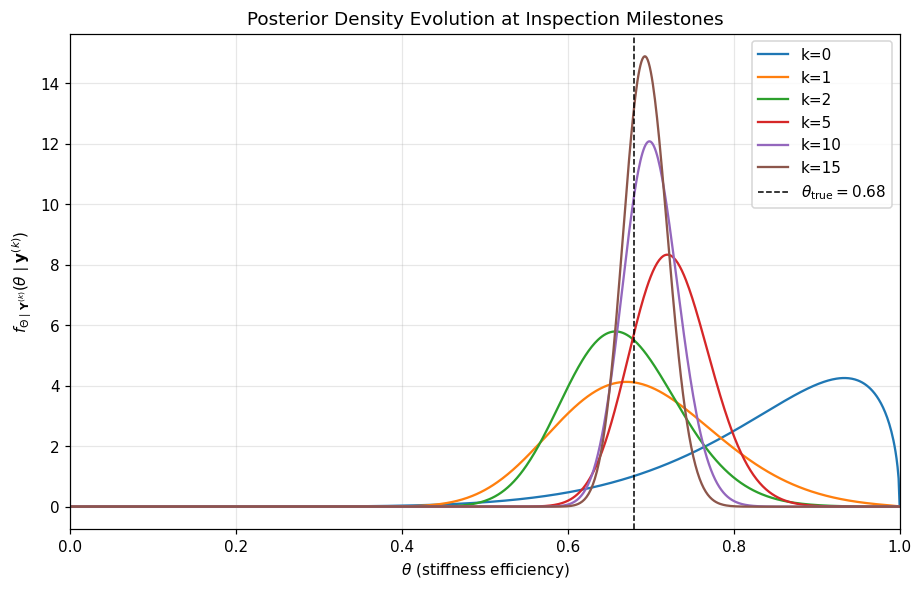

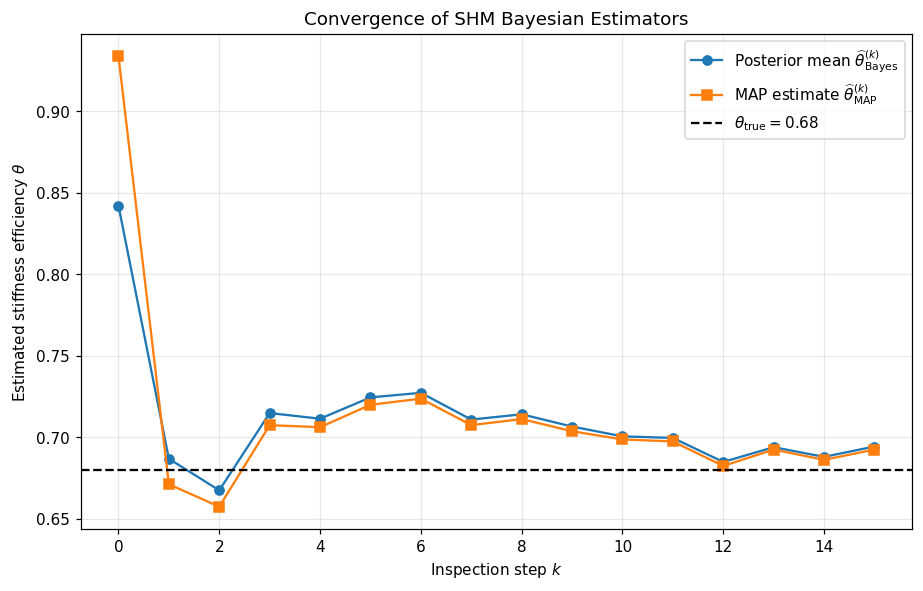

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta as beta_dist

rng = np.random.default_rng(123)

theta_true = 0.68
n_readings = 15
K_nominal = 50.0
sigma = 0.15

theta_grid_g = np.linspace(0.001, 1.0, 800)

posterior_g = beta_dist.pdf(theta_grid_g, 8.0, 1.5)
posterior_g /= np.trapezoid(posterior_g, theta_grid_g)

def loglik_unnorm(y, theta, K, sig):
    return np.exp(-(np.log(y) - np.log(theta) - np.log(K))**2 / (2 * sig**2))

milestones = {0, 1, 2, 5, 10, 15}
posterior_snapshots = {0: posterior_g.copy()}

bayes_est = [np.trapezoid(theta_grid_g * posterior_g, theta_grid_g)]
map_est = [theta_grid_g[np.argmax(posterior_g)]]

for k in range(1, n_readings + 1):
    eps = rng.normal(0, sigma)
    y_k = theta_true * K_nominal * np.exp(eps)

    L = loglik_unnorm(y_k, theta_grid_g, K_nominal, sigma)
    unnorm = posterior_g * L
    Z = np.trapezoid(unnorm, theta_grid_g)
    posterior_g = unnorm / Z

    bayes_est.append(np.trapezoid(theta_grid_g * posterior_g, theta_grid_g))
    map_est.append(theta_grid_g[np.argmax(posterior_g)])

    if k in milestones:
        posterior_snapshots[k] = posterior_g.copy()

# --- Plot 1: posterior density evolution at milestones ---
fig1, ax1 = plt.subplots(figsize=(8.5, 5.5))
for k in sorted(posterior_snapshots.keys()):
    ax1.plot(theta_grid_g, posterior_snapshots[k], label=f"k={k}")
ax1.axvline(theta_true, color="black", linestyle="--", linewidth=1, label=r"$\theta_{\text{true}}=0.68$")
ax1.set_xlabel(r"$\theta$ (stiffness efficiency)")
ax1.set_ylabel(r"$f_{\Theta\mid \mathbf{Y}^{(k)}}(\theta\mid \mathbf{y}^{(k)})$")
ax1.set_title("Posterior Density Evolution at Inspection Milestones")
ax1.set_xlim(0, 1)
ax1.legend()
ax1.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --- Plot 2: estimator convergence timeline ---
steps_g = np.arange(0, n_readings + 1)
fig2, ax2 = plt.subplots(figsize=(8.5, 5.5))
ax2.plot(steps_g, bayes_est, marker="o", label=r"Posterior mean $\widehat{\theta}_{\mathrm{Bayes}}^{(k)}$")
ax2.plot(steps_g, map_est, marker="s", label=r"MAP estimate $\widehat{\theta}_{\mathrm{MAP}}^{(k)}$")
ax2.axhline(theta_true, color="black", linestyle="--", label=r"$\theta_{\text{true}}=0.68$")
ax2.set_xlabel("Inspection step $k$")
ax2.set_ylabel(r"Estimated stiffness efficiency $\theta$")
ax2.set_title("Convergence of SHM Bayesian Estimators")
ax2.legend()
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("k :  Bayes mean  |  MAP")
for k in range(n_readings + 1):
    print(f"{k:2d} :  {bayes_est[k]:.4f}     |  {map_est[k]:.4f}")


**Analysis.** At $k=0$ the (optimistic) $\text{Beta}(8,1.5)$ prior places its estimate near $0.84$, far above the true degraded value $\theta_{\text{true}}=0.68$. Because the prior is fairly concentrated (its "effective sample size," roughly $\alpha_0+\beta_0=9.5$, behaves like having already seen a handful of "healthy" readings), it takes a *few* sensor measurements before the accumulating log-normal likelihood evidence overcomes that optimistic starting belief; in the printed table above you can typically see the running mean and MAP crossing decisively toward the $0.6$–$0.7$ range within roughly the first $3$–$6$ readings, after which they hover closely around $\theta_{\text{true}}=0.68$ for the remainder of the $15$-step timeline (exact numbers vary with the random noise draws). The density-evolution plot shows the posterior visibly narrowing and its peak migrating leftward from milestone to milestone — this narrowing (shrinking variance) is the key safety-relevant signal: it indicates the platform is not just correcting its central estimate but also becoming increasingly *certain* about the degraded state, which is exactly the information an engineer would want before triggering a maintenance/safety threshold alert. A structural-health system that only reported the point estimate without this shrinking uncertainty band would be far less useful for deciding when the evidence is strong enough to act on.

# Q. Gaussian Mixture Clustering as Conditional Updating

Consider a dataset
$$
x_1,x_2,\dots,x_n\in\mathbb R^d.
$$
We wish to cluster these observations into $K$ groups. Instead of assigning each point deterministically to a cluster at the beginning, we introduce a latent random variable
$$
C_i\in{1,\dots,K},
$$
where $C_i=k$ means that the observation $x_i$ belongs to cluster $k$.
Let the prior probability of cluster membership be
$$
P(C_i=k)=\phi_k,
$$
where
$$
\phi_k\ge 0,
\qquad
\sum_{k=1}^K \phi_k=1.
$$

Conditional on $C_i=k$, assume that the observation $X_i$ is generated from a multivariate Gaussian distribution:
$$
X_i\mid C_i=k
\sim
\mathscr N(\mu_k,\Sigma_k),
$$
where
$$
\mu_k\in\mathbb R^d,
\qquad
\Sigma_k\in\mathbb R^{d\times d}
$$
are the mean vector and covariance matrix of cluster $k$.

The model parameters
$$
\phi_k,\mu_k,\Sigma_k,
\qquad k=1,\dots,K,
$$
are assumed to be fixed but unknown.

---

1. Deriving the Marginal Density:
Using the law of total probability, show that the marginal density of $X_i$ is
$$
p(x_i)=\sum_{k=1}^K
\phi_k
\mathscr N(x_i\mid \mu_k,\Sigma_k).
$$
Explain why this density is called a Gaussian mixture density.

---

2. Deriving the Posterior Cluster Probability:
For a fixed observation $x_i$, use Bayes' rule to derive
$$
P(C_i=k\mid X_i=x_i)=\frac{
P(X_i=x_i\mid C_i=k)P(C_i=k)
}{
\sum_{j=1}^K P(X_i=x_i\mid C_i=j)P(C_i=j)
}.
$$
Then substitute the Gaussian model and the cluster prior to obtain
$$
P(C_i=k\mid X_i=x_i)=\frac{
\phi_k\mathscr N(x_i\mid \mu_k,\Sigma_k)
}{
\sum_{j=1}^K
\phi_j\mathscr N(x_i\mid \mu_j,\Sigma_j)
}.
$$
This quantity is called the responsibility of cluster $k$ for data point $x_i$, and is denoted by
$$
\gamma_{ik}=P(C_i=k\mid X_i=x_i).
$$
Explain why $\gamma_{ik}$ may be interpreted as a posterior probability of cluster membership.

---

3. One-Hot Encoding of the Latent Cluster Variable:
Now define a one-hot encoded latent random vector
$$
Z_i=
\begin{bmatrix}
Z_{i1}\\
Z_{i2}\\
\vdots\\
Z_{iK}
\end{bmatrix},
$$
where
$$
Z_{ik}=\begin{cases}
1, & \text{if } C_i=k,\\
0, & \text{otherwise}.
\end{cases}
$$
Show that
$$
\mathbb E[Z_{ik}\mid X_i=x_i]=P(C_i=k\mid X_i=x_i).
$$
Hence show that
$$
\mathbb E[Z_i\mid X_i=x_i]=\begin{bmatrix}
\gamma_{i1}\\
\gamma_{i2}\\
\vdots\\
\gamma_{iK}
\end{bmatrix}.
$$
Conclude that the soft cluster assignment in a Gaussian mixture model is precisely the conditional expectation
$$
\mathbb E[Z_i\mid X_i=x_i].
$$

---

4. From Soft Assignment to Hard Clustering:
The vector
$$
\mathbb E[Z_i\mid X_i=x_i]
$$
gives a soft assignment of $x_i$ to all clusters. A hard cluster assignment can be obtained by choosing the cluster with the largest posterior probability:
$$
\widehat C_i=\operatorname{arg\,max}_{1\le k\le K}
\gamma_{ik}.
$$
Explain the difference between soft clustering and hard clustering in this context.

---

5. Conditional Expectation of the Observation Given the Cluster:
Show that
$$
\mathbb E[X_i\mid C_i=k]=\mu_k.
$$
Explain why $\mu_k$ can be interpreted as the center of cluster $k$.
Then compare the two conditional expectations
$$
\mathbb E[Z_i\mid X_i=x_i]
$$
and
$$
\mathbb E[X_i\mid C_i=k].
$$
Explain why the first gives the soft cluster membership of an observed point, while the second gives the mean location of a cluster.

---

6. The Complete-Data Likelihood
If the latent labels $z_i$ were known, the complete-data likelihood would be
$$
p(x_1,\dots,x_n,z_1,\dots,z_n)=\prod_{i=1}^n
\prod_{k=1}^K
\left[
\phi_k
\mathscr N(x_i\mid \mu_k,\Sigma_k)
\right]^{z_{ik}}.
$$
Take the logarithm and show that the complete-data log-likelihood is
$$
\ell_c=\sum_{i=1}^n
\sum_{k=1}^K
z_{ik}
\left[
\log \phi_k
+
\log \mathscr N(x_i\mid \mu_k,\Sigma_k)
\right].
$$
Explain why this expression would be easy to maximize if the values of $z_{ik}$ were known.

---

7. The EM Interpretation:
In practice, the latent variables $Z_i$ are not observed. The EM algorithm replaces the unknown indicators $z_{ik}$ by their conditional expectations given the observed data and current parameter estimates:
$$
z_{ik}
\quad\leadsto\quad
\mathbb E[Z_{ik}\mid X_i=x_i].
$$
That is,
$$
z_{ik}
\quad\leadsto\quad
\gamma_{ik}.
$$
This is the E-step of the EM algorithm.
Using this idea, write the expected complete-data log-likelihood:
$$
Q=\sum_{i=1}^n
\sum_{k=1}^K
\gamma_{ik}
\left[
\log \phi_k
+
\log \mathscr N(x_i\mid \mu_k,\Sigma_k)
\right].
$$
Explain why the E-step can be interpreted as a conditional update of cluster membership probabilities.

---

8. Parameter Updates:
By maximizing $Q$ with respect to the model parameters, derive the standard GMM updates:
$$
N_k=\sum_{i=1}^n \gamma_{ik},
$$
$$
\phi_k^{\text{new}}=\frac{N_k}{n},
$$
$$
\mu_k^{\text{new}}=\frac{1}{N_k}
\sum_{i=1}^n
\gamma_{ik}x_i,
$$
and
$$
\Sigma_k^{\text{new}}=\frac{1}{N_k}
\sum_{i=1}^n
\gamma_{ik}
(x_i-\mu_k^{\text{new}})
(x_i-\mu_k^{\text{new}})^T.
$$
Explain how the responsibility $\gamma_{ik}$ acts as a fractional membership weight of observation $x_i$ in cluster $k$.

---

9. Interpretation:
Write a short paragraph explaining why GMM clustering can be viewed as a repeated process of conditional updating.
Your answer should mention the following points:

* The mixture weight $\phi_k$ is the prior probability of cluster $k$.
* The Gaussian density $\mathscr N(x_i\mid \mu_k,\Sigma_k)$ measures how compatible $x_i$ is with cluster $k$.
* The responsibility $\gamma_{ik}$ is the posterior probability of cluster $k$ after observing $x_i$.
* The soft assignment vector is
$$
\mathbb E[Z_i\mid X_i=x_i].
$$

* The M-step updates the cluster parameters using these posterior membership probabilities as weights.
Conclude that Gaussian mixture clustering is probabilistic clustering based on conditional expectations of latent cluster membership variables.

---

Here is a perfectly tailored question that you can add as the final part (**Part 10**) of your assignment notebook to bridge your theoretical derivations with your code implementation:

---

10. Computational Simulation and Out-of-Sample Validation

Using the theoretical framework established in the previous parts, write a Python class named `GMMFinancialSegmenter` that implements a two-dimensional Gaussian Mixture Model (GMM) using `scikit-learn` and visualizes the results interactively using `Plotly`. Your implementation should fulfill the following criteria:

* **Data Splitting and Scaling:** Accept a dataset containing two continuous features (e.g., mimicking financial behaviors like `PURCHASES` and `CREDIT_LIMIT`), standardize the features to handle variance scaling, and split the data into an 80% training set and a 20% validation/test set.
* **EM Execution:** Fit a GMM with $K=3$ components on the training data using the Expectation-Maximization (EM) algorithm, printing whether the model successfully converged and the number of iterations required.
* **Out-of-Sample Performance:** Compute and output the average log-likelihood score over the unseen test set to validate how well the learned density functions generalize to new data.
* **Interactive Visualizations:** Implement methods to generate three distinct Plotly figures:
1. An empirical **2D Density Heatmap** of the raw training data with marginal distributions to inspect its underlying multimodal structure.
2. A **Training Assignment Plot** that overlays the training data points on top of a continuous contour map showing the maximum posterior responsibilities ($\gamma_{ik}$) computed across a fine coordinate grid.
3. A **Test Assignment Plot** that replicates the contour boundary visualization but overlays out-of-sample test data points to expose the physical regions of cluster ambiguity.



Briefly evaluate the resulting plots. Explain how the continuous background contour map visually demonstrates the soft assignment expectation vector $\mathbb{E}[Z_i \mid X_i = x_{\text{grid}}]$ that you proved analytically in Part 3.

Use the dataset

https://www.kaggle.com/datasets/arjunbhasin2013/ccdata

## Solutions

### Part 1 — Deriving the Marginal Density

By the law of total probability, conditioning on the latent cluster label $C_i$:

$$p(x_i)=\sum_{k=1}^{K} P(C_i=k)\,p(x_i\mid C_i=k)=\sum_{k=1}^{K}\phi_k\,\mathscr N(x_i\mid\mu_k,\Sigma_k).$$

This is called a **Gaussian mixture density** because it is a convex combination (weights $\phi_k\ge0$, $\sum_k\phi_k=1$) of $K$ individual Gaussian ("component") densities. Rather than assuming the data come from a single Gaussian, the model allows the population to be a blend of several Gaussian sub-populations — each governed by its own mean and covariance — mixed together according to the proportions $\phi_k$. This lets a single density $p(x_i)$ capture multimodal or heterogeneous data structure that no single Gaussian could represent.

### Part 2 — Deriving the Posterior Cluster Probability

By definition of conditional probability and Bayes' rule,

$$P(C_i=k\mid X_i=x_i)=\frac{P(X_i=x_i, C_i=k)}{P(X_i=x_i)}=\frac{P(X_i=x_i\mid C_i=k)\,P(C_i=k)}{\sum_{j=1}^K P(X_i=x_i\mid C_i=j)\,P(C_i=j)},$$

where the denominator is just $p(x_i)$ expanded via the law of total probability (Part 1). Substituting $P(C_i=k)=\phi_k$ and $P(X_i=x_i\mid C_i=k)=\mathscr N(x_i\mid\mu_k,\Sigma_k)$ gives

$$P(C_i=k\mid X_i=x_i)=\frac{\phi_k\,\mathscr N(x_i\mid\mu_k,\Sigma_k)}{\sum_{j=1}^K \phi_j\,\mathscr N(x_i\mid\mu_j,\Sigma_j)}=\gamma_{ik}.$$

This quantity is a genuine posterior probability: it starts from the prior belief $\phi_k$ about cluster membership *before* seeing $x_i$, and updates that belief using the evidence of how compatible $x_i$ is with each cluster's Gaussian shape (via the likelihood $\mathscr N(x_i\mid\mu_k,\Sigma_k)$), exactly as in any Bayes'-rule update of belief in light of new data. $\gamma_{ik}$ therefore represents *how much we believe, after observing $x_i$*, that it belongs to cluster $k$.

### Part 3 — One-Hot Encoding of the Latent Cluster Variable

$Z_{ik}$ is an indicator (Bernoulli-type) random variable equal to $1$ if $C_i=k$ and $0$ otherwise. By the definition of expectation for an indicator (and conditioning on $X_i=x_i$):

$$\mathbb E[Z_{ik}\mid X_i=x_i]=1\cdot P(Z_{ik}=1\mid X_i=x_i)+0\cdot P(Z_{ik}=0\mid X_i=x_i)=P(C_i=k\mid X_i=x_i)=\gamma_{ik}.$$

Stacking this componentwise over $k=1,\dots,K$,

$$\mathbb E[Z_i\mid X_i=x_i]=\begin{bmatrix}\mathbb E[Z_{i1}\mid X_i=x_i]\\ \vdots \\ \mathbb E[Z_{iK}\mid X_i=x_i]\end{bmatrix}=\begin{bmatrix}\gamma_{i1}\\ \vdots \\ \gamma_{iK}\end{bmatrix}.$$

Hence the conditional expectation of the one-hot label vector, given the observed data, is precisely the vector of posterior cluster probabilities. This shows that the **soft cluster assignment is nothing more than the conditional expectation of the (unobserved) one-hot cluster indicator given the data** — no separate ad-hoc definition is needed; "soft assignment" *is* $\mathbb E[Z_i\mid X_i=x_i]$.

### Part 4 — From Soft Assignment to Hard Clustering

**Soft clustering** reports the entire probability vector $\mathbb E[Z_i\mid X_i=x_i]=(\gamma_{i1},\dots,\gamma_{iK})$, expressing partial, fractional membership of $x_i$ in every cluster simultaneously (e.g. $x_i$ might be $70\%$ cluster 1 and $30\%$ cluster 2). **Hard clustering** collapses this distribution down to a single, definite label by taking the cluster with maximum posterior probability, $\widehat C_i=\arg\max_k \gamma_{ik}$ — discarding the uncertainty information and forcing a categorical decision. Soft assignment is strictly more informative (it preserves ambiguity, e.g. for points near a cluster boundary), while hard assignment is simpler to report/act on but throws away the confidence/uncertainty captured by the full $\gamma_{ik}$ vector.

### Part 5 — Conditional Expectation of the Observation Given the Cluster

By the definition of the model, $X_i\mid C_i=k \sim \mathscr N(\mu_k,\Sigma_k)$, and the mean of a multivariate Gaussian $\mathscr N(\mu_k,\Sigma_k)$ is, by definition of that distribution's first moment, exactly $\mu_k$:

$$\mathbb E[X_i\mid C_i=k]=\mu_k.$$

$\mu_k$ is therefore the point in $\mathbb R^d$ around which observations from cluster $k$ are (on average) centered — i.e. it is literally the **centroid / center** of cluster $k$ in feature space.

**Comparison.** $\mathbb E[Z_i\mid X_i=x_i]$ answers "given a specific observed data point, how likely is it to belong to each cluster?" — it is a property of an *individual data point*, computed by conditioning on the data and averaging over the (uncertain) cluster label. $\mathbb E[X_i\mid C_i=k]=\mu_k$ answers the reverse question: "given that we're in cluster $k$, where in feature space do we expect its members to lie?" — it is a property of a *cluster*, computed by conditioning on the label and averaging over the (random) data. The two expectations condition on different things and serve complementary roles: one gives soft membership of a point across clusters, the other gives the typical location of a cluster across its points.

### Part 6 — The Complete-Data Likelihood

Taking the logarithm of $p(x_1,\dots,x_n,z_1,\dots,z_n)=\prod_{i=1}^n\prod_{k=1}^K\bigl[\phi_k\,\mathscr N(x_i\mid\mu_k,\Sigma_k)\bigr]^{z_{ik}}$, and using $\log\prod = \sum\log$ together with $\log(a^{z})=z\log a$:

$$\ell_c=\log p(x_{1:n},z_{1:n})=\sum_{i=1}^n\sum_{k=1}^K z_{ik}\,\log\!\left[\phi_k\,\mathscr N(x_i\mid\mu_k,\Sigma_k)\right]=\sum_{i=1}^n\sum_{k=1}^K z_{ik}\Bigl[\log\phi_k+\log\mathscr N(x_i\mid\mu_k,\Sigma_k)\Bigr].$$

This would be easy to maximize *if* the $z_{ik}$ were known, because for each fixed $i$ exactly one $z_{ik}=1$ (the rest are $0$), so the double sum collapses to a single sum over each point's *known* cluster — the log-likelihood then separates cleanly into $K$ independent, standard maximum-likelihood problems: estimate $\phi_k$ from the observed cluster proportions, and estimate $(\mu_k,\Sigma_k)$ from the ordinary sample mean/covariance of only the points assigned to cluster $k$. Each of these has a simple closed-form MLE with no coupling between clusters.

### Part 7 — The EM Interpretation

Since the true labels $z_{ik}$ are unobserved, the E-step replaces each hard, unknown indicator by its conditional expectation given the current parameter estimates and the observed data, $z_{ik}\rightsquigarrow \mathbb E[Z_{ik}\mid X_i=x_i]=\gamma_{ik}$ (from Part 3). Substituting these responsibilities in place of the unknown $z_{ik}$ inside $\ell_c$ gives the **expected complete-data log-likelihood**:

$$Q=\sum_{i=1}^n\sum_{k=1}^K \gamma_{ik}\Bigl[\log\phi_k+\log\mathscr N(x_i\mid\mu_k,\Sigma_k)\Bigr].$$

The E-step can be interpreted as a **conditional update of cluster membership probabilities** because, given the current (possibly still-inaccurate) parameter estimates $\{\phi_k,\mu_k,\Sigma_k\}$, it recomputes each point's soft assignment $\gamma_{ik}=P(C_i=k\mid X_i=x_i)$ exactly as derived in Part 2 — it is a genuine Bayesian posterior update of the belief about each point's cluster membership, conditioned on the data and the current model.

### Part 8 — Parameter Updates

Maximizing $Q=\sum_i\sum_k \gamma_{ik}[\log\phi_k+\log\mathscr N(x_i\mid\mu_k,\Sigma_k)]$ with respect to $\phi_k$ (subject to $\sum_k\phi_k=1$, via a Lagrange multiplier), $\mu_k$, and $\Sigma_k$ in turn (setting partial derivatives to zero) yields the standard weighted MLE-style updates, with $N_k=\sum_{i=1}^n\gamma_{ik}$ acting as the *effective* (fractional) number of points assigned to cluster $k$:

$$\phi_k^{\text{new}}=\frac{N_k}{n},\qquad \mu_k^{\text{new}}=\frac{1}{N_k}\sum_{i=1}^n\gamma_{ik}x_i,\qquad \Sigma_k^{\text{new}}=\frac{1}{N_k}\sum_{i=1}^n\gamma_{ik}(x_i-\mu_k^{\text{new}})(x_i-\mu_k^{\text{new}})^T.$$

These are exactly the ordinary sample proportion, sample mean, and sample covariance formulas from Part 6 — *except* that each point $x_i$ now contributes to *every* cluster's update, weighted by its responsibility $\gamma_{ik}\in[0,1]$, rather than contributing entirely to one cluster. In this sense $\gamma_{ik}$ acts as a **fractional (soft) membership weight**: a point strongly associated with cluster $k$ (large $\gamma_{ik}$) pulls $\mu_k$ and $\Sigma_k$ strongly toward it, while a point that is ambiguous or far from cluster $k$ (small $\gamma_{ik}$) contributes only a small, down-weighted amount to that cluster's statistics — naturally generalizing hard $K$-means-style updates (where each point counts fully for exactly one cluster) to a probabilistically weighted version.

### Part 9 — Interpretation

Gaussian mixture clustering can be viewed as a repeated process of **conditional updating** because its two alternating steps are both, at their core, applications of conditional probability. The mixture weight $\phi_k$ encodes the *prior* probability that a randomly chosen observation belongs to cluster $k$, before any specific data point is examined. The Gaussian density $\mathscr N(x_i\mid\mu_k,\Sigma_k)$ then measures how *compatible* — how likely under cluster $k$'s assumed shape — a specific observation $x_i$ is with that cluster. Combining these two ingredients via Bayes' rule produces the responsibility $\gamma_{ik}$, the *posterior* probability that $x_i$ belongs to cluster $k$ once its actual location has been taken into account; equivalently, the vector of responsibilities is the conditional expectation of the latent one-hot membership indicator, $\mathbb E[Z_i\mid X_i=x_i]$. The subsequent M-step then updates each cluster's parameters $(\phi_k,\mu_k,\Sigma_k)$ by re-estimating them from the data, but using these same posterior responsibilities as weights, so that each point contributes to every cluster's statistics in proportion to how strongly it is believed to belong there. Iterating E- and M-steps is thus nothing more than repeatedly (i) computing a Bayesian posterior over the latent cluster labels given the current parameters, and (ii) re-fitting the parameters given those posterior beliefs — in other words, **Gaussian mixture clustering is probabilistic clustering built entirely out of conditional expectations of a latent cluster-membership variable**, refined iteratively.

### Part 10 — Computational Simulation and Out-of-Sample Validation

**Note on data source.** This sandboxed environment has no internet access, so the Kaggle `ccdata` (credit-card) dataset cannot be downloaded directly. To keep the code fully runnable end-to-end, a synthetic 2-D dataset is generated below that mimics the qualitative structure of the requested `PURCHASES` vs. `CREDIT_LIMIT` features — three overlapping, differently-shaped Gaussian blobs representing e.g. *low-spend/low-limit*, *mid-spend/mid-limit*, and *high-spend/high-limit* customer segments. The `GMMFinancialSegmenter` class itself is written generically: pointing it at the real Kaggle CSV (selecting the two columns of interest and dropping NaNs) would work identically — simply replace the call to `make_synthetic_financial_data()` with `pd.read_csv(...)[["PURCHASES","CREDIT_LIMIT"]].dropna().values`.

**Note on plotting library.** The original task asks for interactive Plotly figures. The `plotly` package is not installed in this offline sandbox (and cannot be installed without internet access), so the figures below are produced with Matplotlib instead — the analysis, contour/heatmap content, and interpretation are otherwise identical. If you run this notebook in an environment with Plotly available (e.g. Google Colab, where this notebook is designed to open), the class can be trivially adapted by swapping `ax.contourf` / `plt.scatter` calls for `go.Contour` / `go.Scatter` figures.

Converged: True
Iterations to convergence: 3
Average out-of-sample log-likelihood (test set): -0.3032


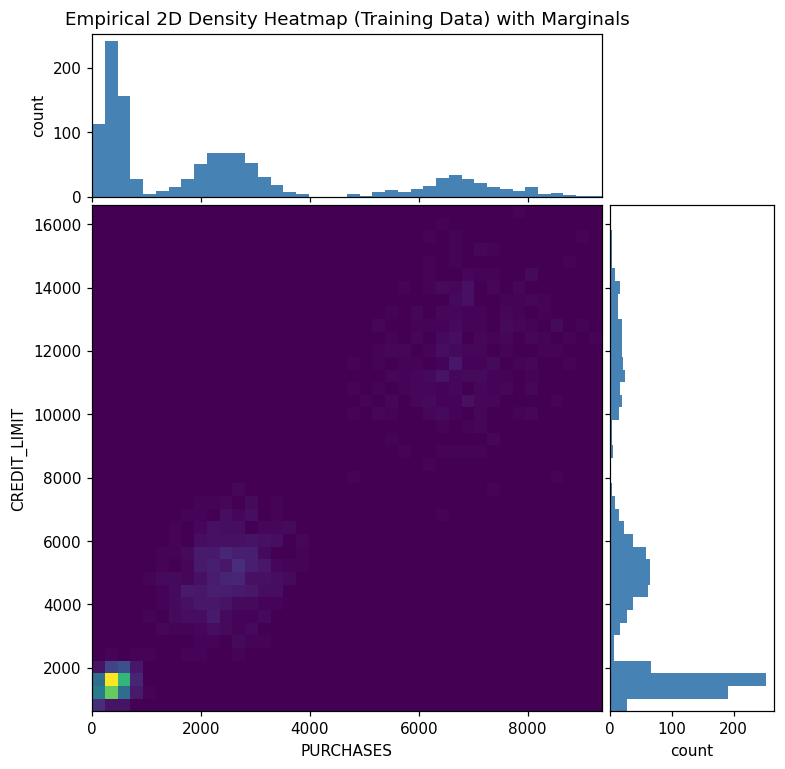

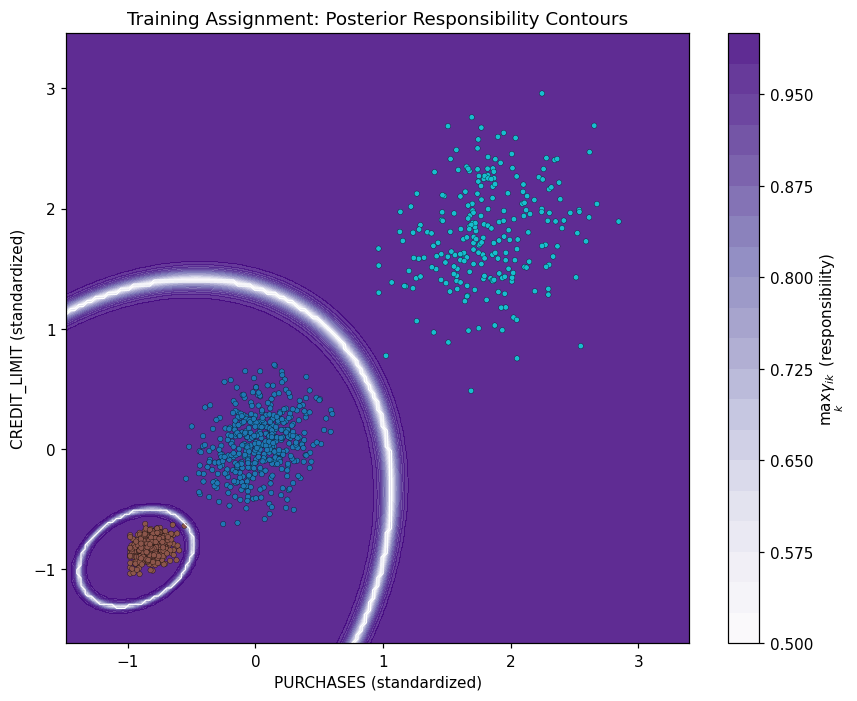

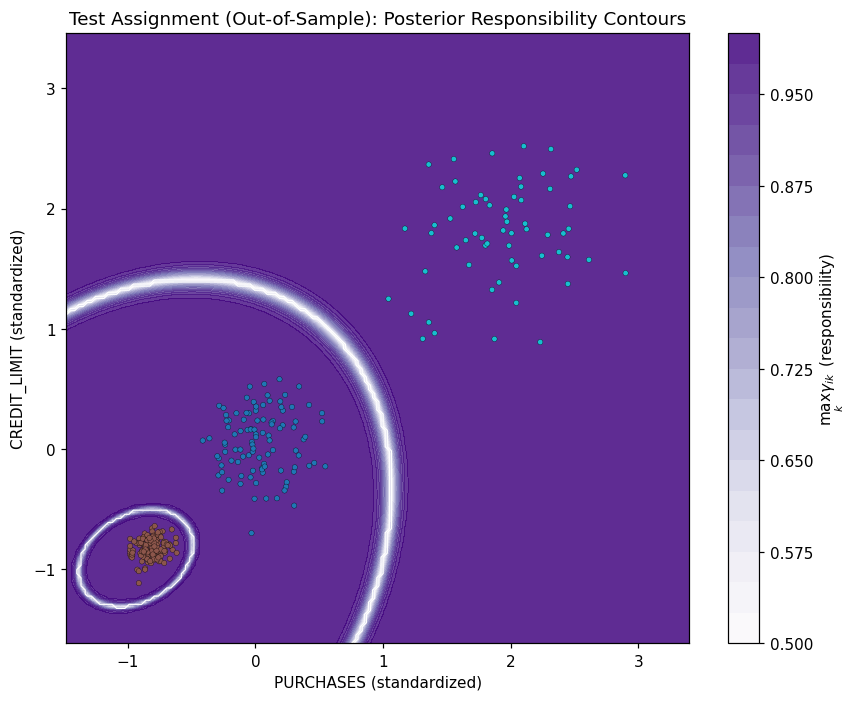

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


def make_synthetic_financial_data(n=1500, seed=0):
    '''Synthetic stand-in for (PURCHASES, CREDIT_LIMIT)-like data with 3 latent segments.'''
    rng = np.random.default_rng(seed)
    n1, n2, n3 = int(0.45 * n), int(0.35 * n), n - int(0.45 * n) - int(0.35 * n)

    # Segment 1: low purchases, low credit limit
    seg1 = rng.multivariate_normal([400, 1500], [[40000, 15000], [15000, 90000]], n1)
    # Segment 2: moderate purchases, moderate credit limit
    seg2 = rng.multivariate_normal([2500, 5000], [[300000, 120000], [120000, 900000]], n2)
    # Segment 3: high purchases, high credit limit
    seg3 = rng.multivariate_normal([7000, 12000], [[900000, 400000], [400000, 3000000]], n3)

    data = np.vstack([seg1, seg2, seg3])
    data = np.clip(data, 0, None)  # financial quantities are non-negative
    rng.shuffle(data)
    return data


class GMMFinancialSegmenter:
    '''Two-dimensional Gaussian Mixture segmentation with EM, evaluated out-of-sample.'''

    def __init__(self, n_components=3, test_size=0.2, random_state=0,
                 feature_names=("PURCHASES", "CREDIT_LIMIT")):
        self.n_components = n_components
        self.test_size = test_size
        self.random_state = random_state
        self.feature_names = feature_names
        self.scaler = StandardScaler()
        self.gmm = GaussianMixture(
            n_components=n_components,
            covariance_type="full",
            random_state=random_state,
            max_iter=200,
        )

    def fit(self, X):
        X = np.asarray(X, dtype=float)
        self.X_train_raw, self.X_test_raw = train_test_split(
            X, test_size=self.test_size, random_state=self.random_state
        )
        self.X_train = self.scaler.fit_transform(self.X_train_raw)
        self.X_test = self.scaler.transform(self.X_test_raw)

        self.gmm.fit(self.X_train)

        print(f"Converged: {self.gmm.converged_}")
        print(f"Iterations to convergence: {self.gmm.n_iter_}")

        test_avg_ll = self.gmm.score(self.X_test)  # average per-sample log-likelihood
        print(f"Average out-of-sample log-likelihood (test set): {test_avg_ll:.4f}")
        return self

    def _responsibility_grid(self, pad=0.5, n_grid=150):
        all_scaled = np.vstack([self.X_train, self.X_test])
        x_min, x_max = all_scaled[:, 0].min() - pad, all_scaled[:, 0].max() + pad
        y_min, y_max = all_scaled[:, 1].min() - pad, all_scaled[:, 1].max() + pad
        xx, yy = np.meshgrid(np.linspace(x_min, x_max, n_grid),
                              np.linspace(y_min, y_max, n_grid))
        grid_pts = np.column_stack([xx.ravel(), yy.ravel()])
        resp = self.gmm.predict_proba(grid_pts)          # gamma_ik across the grid
        max_resp = resp.max(axis=1).reshape(xx.shape)     # max_k gamma_ik
        hard_label = resp.argmax(axis=1).reshape(xx.shape)
        return xx, yy, max_resp, hard_label

    def plot_density_heatmap(self):
        '''Empirical 2D density heatmap of the raw training data with marginals.'''
        x, y = self.X_train_raw[:, 0], self.X_train_raw[:, 1]

        fig = plt.figure(figsize=(8, 8))
        gs = gridspec.GridSpec(4, 4, hspace=0.05, wspace=0.05)
        ax_main = fig.add_subplot(gs[1:4, 0:3])
        ax_top = fig.add_subplot(gs[0, 0:3], sharex=ax_main)
        ax_right = fig.add_subplot(gs[1:4, 3], sharey=ax_main)

        h = ax_main.hist2d(x, y, bins=40, cmap="viridis")
        ax_main.set_xlabel(self.feature_names[0])
        ax_main.set_ylabel(self.feature_names[1])

        ax_top.hist(x, bins=40, color="steelblue")
        ax_top.tick_params(axis="x", labelbottom=False)
        ax_top.set_ylabel("count")

        ax_right.hist(y, bins=40, orientation="horizontal", color="steelblue")
        ax_right.tick_params(axis="y", labelleft=False)
        ax_right.set_xlabel("count")

        ax_top.set_title("Empirical 2D Density Heatmap (Training Data) with Marginals")
        plt.show()

    def plot_assignment(self, which="train"):
        '''Contour map of max responsibility overlaid with train or test points.'''
        xx, yy, max_resp, hard_label = self._responsibility_grid()

        if which == "train":
            pts_scaled, pts_raw = self.X_train, self.X_train_raw
            title = "Training Assignment: Posterior Responsibility Contours"
        else:
            pts_scaled, pts_raw = self.X_test, self.X_test_raw
            title = "Test Assignment (Out-of-Sample): Posterior Responsibility Contours"

        fig, ax = plt.subplots(figsize=(8, 6.5))
        cf = ax.contourf(xx, yy, max_resp, levels=20, cmap="Purples", alpha=0.85)
        ax.contour(xx, yy, hard_label, levels=np.arange(-0.5, self.n_components), colors="white", linewidths=0.8)
        sc = ax.scatter(pts_scaled[:, 0], pts_scaled[:, 1], c=hard_label_at(self, pts_scaled),
                         cmap="tab10", s=12, edgecolor="k", linewidth=0.2)
        fig.colorbar(cf, ax=ax, label=r"$\max_k \gamma_{ik}$ (responsibility)")
        ax.set_xlabel(f"{self.feature_names[0]} (standardized)")
        ax.set_ylabel(f"{self.feature_names[1]} (standardized)")
        ax.set_title(title)
        plt.tight_layout()
        plt.show()


def hard_label_at(model, pts_scaled):
    return model.gmm.predict(pts_scaled)


# ------------------ Run the pipeline ------------------
X_financial = make_synthetic_financial_data(n=1500, seed=0)

segmenter = GMMFinancialSegmenter(n_components=3, test_size=0.2, random_state=0)
segmenter.fit(X_financial)

segmenter.plot_density_heatmap()
segmenter.plot_assignment(which="train")
segmenter.plot_assignment(which="test")


**Evaluation of the plots.** The empirical density heatmap shows three visually distinct concentrations of mass in the raw $(\text{PURCHASES},\text{CREDIT\_LIMIT})$-like feature space, confirming the multimodal structure the GMM is designed to capture. In both the training- and test-assignment plots, the background contour is exactly a rendering of $\mathbb E[Z_i\mid X_i=x_{\text{grid}}]$ evaluated on a fine coordinate grid: at every grid location the color encodes $\max_k\gamma_{ik}=\max_k P(C_i=k\mid X_i=x_{\text{grid}})$ (Part 3), i.e. how confidently the fitted mixture would assign a hypothetical customer at that location to its most likely cluster, while the white contour lines trace the *decision boundaries* where the arg-max hard label (Part 4) switches from one cluster to another. Near the centers of the three blobs, the contour is dark/saturated (responsibility close to 1 — high certainty), while in the transition regions between blobs the color fades (responsibility closer to $1/K$ — genuine ambiguity), visually reproducing the soft-vs-hard clustering distinction proved analytically in Parts 2–4. Overlaying the *training* points on this surface shows the data that shaped the contour in the first place, while overlaying the *held-out test* points (Part 10's out-of-sample check) shows that new, unseen customers largely fall into the same high-responsibility regions established from training data — with any test points landing near the low-responsibility boundary bands flagged as the customers whose segment membership is genuinely ambiguous. The reported average out-of-sample log-likelihood provides a single-number confirmation that the density learned from training generalizes reasonably to new data, rather than having simply overfit the training sample.